# Active Learning for Thermal Comfort — Presentation Notebook

## What I built, what I tested, and what happened

This is the concise presentation copy of `active_learning.ipynb`. Related technical cells have
been combined so the project can be presented as one six-phase story.

**Research question.** Can temperature and relative-humidity patterns be learned through active
learning, and can the model's query behaviour act as a measurable proxy for AI-mediated
interaction?

**Important boundary.** The labels are synthetic PMV-based responses, not real occupant votes.
The classifier receives only indoor temperature and relative humidity. This notebook demonstrates
the proof-of-concept mechanics and evaluates them; it does not validate real-occupant comfort.

### The six phases

1. Data Loading
2. Generating Labels and Preflight
3. Actual Learning Loop — splitting the data and passing it to the loop
4. Results and Evidence — including the successful and failed experiments
5. Validation and Robustness
6. Provenance and Final Conclusion

> **Confidentiality:** the Bath building data and derived outputs are internal project evidence.
Do not upload this notebook or its figures to an external service without permission.

# Phase 1 — Data Loading

## Block 1 — Set up a reproducible analysis

**Why this block exists:** It loads the project modules used throughout the notebook and fixes the
random seed. A fixed seed makes sampling and model training repeatable.

**What to expect:** The output should report seed `42` and identify the two allowed model features:
temperature and relative humidity.

In [1]:
import logging
import subprocess
import sys
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from scipy import stats
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

from dissertation_code import config, pipeline
from dissertation_code.comfort import clothing
from dissertation_code.comfort import pmv as pmv_model
from dissertation_code.comfort import synthetic_labels as sl
from dissertation_code.data import bath, sampling, schema, sources
from dissertation_code.evaluation import analysis, robustness, validation
from dissertation_code.model import active_learning as al
from dissertation_code.utils.seeding import make_reproducible

logging.basicConfig(level=logging.WARNING, format="%(message)s")
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")

make_reproducible()
print(f"Random seed: {config.RANDOM_SEED}")
print(f"Model features: {list(config.COMFORT_VARS)}")

Random seed: 42
Model features: ['temperature', 'relative_humidity']


### Block 1 result

The experiment is reproducible and the modelling boundary is explicit. Outdoor weather may inform
the clothing assumption later, but it is not added to the classifier.

## Block 2 — Load and inspect the complete Bath export

**Why this block exists:** Before modelling, we must confirm the amount of data, the sensor aliases,
room differences and any interruptions in recording.

**What the code does:** It loads the four quarterly workbooks once, combines the sensor names,
profiles every sensor, and checks the largest living-room time gaps.

In [2]:
everything = sources.load_bath_wide(include_external=True)

overview = pd.DataFrame(
    {
        "value": [
            f"{len(everything):,}",
            everything[schema.ZONE].nunique(),
            everything[schema.TIMESTAMP].min(),
            everything[schema.TIMESTAMP].max(),
            int(everything.isna().sum().sum()),
        ]
    },
    index=["readings", "sensors", "first timestamp", "last timestamp", "missing T/RH cells"],
)

profile = (
    everything.groupby(schema.ZONE)
    .agg(
        readings=(schema.TEMPERATURE, "size"),
        temp_min=(schema.TEMPERATURE, "min"),
        temp_mean=(schema.TEMPERATURE, "mean"),
        temp_max=(schema.TEMPERATURE, "max"),
        rh_mean=(schema.RELATIVE_HUMIDITY, "mean"),
    )
)
profile["pct_rh_above_75"] = (
    everything.assign(high=everything[schema.RELATIVE_HUMIDITY] > 75)
    .groupby(schema.ZONE)["high"]
    .mean()
    .mul(100)
)

living = everything.loc[everything[schema.ZONE].eq("livingroom")].sort_values(schema.TIMESTAMP)
largest_gaps = living[schema.TIMESTAMP].diff().nlargest(3).rename("largest living-room gaps")

display(overview)
display(profile.round(1))
display(largest_gaps.to_frame())

,value
readings,"514,030"
sensors,9
first timestamp,2023-11-14 11:20:00
last timestamp,2024-07-10 17:10:00
missing T/RH cells,0


,readings,temp_min,temp_mean,temp_max,rh_mean,pct_rh_above_75
zone,,,,,,
bathroom,62271,11.1,15.4,21.7,69.7,11.2
bedroom,62277,10.9,16.4,20.4,68.1,5.2
external_front,62272,-1.5,11.2,27.1,87.5,80.8
external_rear,32156,4.7,13.5,23.7,78.6,64.1
hall,45966,13.2,16.3,20.7,67.4,1.8
kitchen,62272,10.5,14.3,22.9,77.8,66.2
livingroom,62270,10.6,15.0,21.5,71.1,17.6
spareroom,62274,10.4,15.0,20.7,71.7,20.2
study,62272,10.5,15.1,21.1,70.8,13.9


,largest living-room gaps
343521,16 days 09:10:00
373637,6 days 12:50:00
357330,0 days 01:10:00


### Block 2 result

- The loader finds **514,030 readings from 9 sensors**, covering November 2023 to July 2024.
- Recorded rows contain no missing temperature or RH cells.
- Indoor means are cool, while the kitchen is the humidity outlier at about **77.8% mean RH** and
  roughly **66.2% of readings above 75% RH**.
- The largest time gap is about **16 days 9 hours**. Therefore, complete rows do not imply
  continuous monitoring, and the notebook does not invent values across the gaps.

# Phase 2 — Generating Labels and Preflight

The sensor files have no occupant comfort answers. This phase creates the hidden synthetic labels
used as the active-learning oracle, then checks whether those labels contain enough signal to learn.

## Why the project needs a clothing assumption

PMV cannot be calculated from temperature and relative humidity alone. It also needs metabolic
rate, clothing insulation, air speed and mean radiant temperature. The Bath sensors do not measure
an occupant's clothing, so a clothing value must either be assumed or estimated before synthetic
comfort labels can be generated.

The project therefore treats clothing as a **modelling assumption that must be tested against the
target building**, not as known occupant information.

## Block 3A — First attempt failed: fixed 0.5 clo

**Why I tried it first:** `0.5 clo` is a recognised light-clothing reference, roughly corresponding
to a short-sleeved shirt and trousers. It provided a transparent starting value when no clothing
measurements were available.

This was a starting hypothesis—not a claim that Bath occupants actually wore `0.5 clo`. The code
below tests whether that hypothesis produces a usable comfort boundary on the target data.

**Audit trail:** The value entered the project in the Sprint 1 PMV implementation
(`b8e8564`, `dissertation_code/config.py`). It was an implementation reference and was not supplied
by either sensor dataset.

**What the code tests:** It applies fixed `0.5 clo` to every Bath indoor reading, measures how much
of the building falls below the PMV cold boundary, and shows how clothing changes PMV at typical
Bath conditions.

In [3]:
is_external = everything[schema.ZONE].isin(bath.EXTERNAL_SENSORS)
indoor = everything.loc[~is_external].copy()
external = everything.loc[is_external].copy()

fixed_half_pmv = pmv_model.pmv_series(
    indoor[schema.TEMPERATURE],
    indoor[schema.RELATIVE_HUMIDITY],
    np.full(len(indoor), 0.5),
)
fixed_half_labels = sl.generate_labels(
    indoor,
    sl.GeneratorConfig(
        assumptions=pmv_model.ComfortAssumptions(clothing_insulation=0.5),
        merge_warm=True,
    ),
)

fixed_assessment = indoor[[schema.ZONE]].copy()
fixed_assessment["PMV"] = fixed_half_pmv
fixed_assessment["below PMV cold boundary"] = fixed_half_pmv < -config.PMV_NEUTRAL_BAND
fixed_room_summary = (
    fixed_assessment.groupby(schema.ZONE)
    .agg(
        mean_PMV=("PMV", "mean"),
        pct_below_cold_boundary=("below PMV cold boundary", "mean"),
    )
)
fixed_room_summary["pct_below_cold_boundary"] *= 100

fixed_summary = pd.Series(
    {
        "indoor readings": len(indoor),
        "mean PMV": fixed_half_pmv.mean(),
        "minimum PMV": fixed_half_pmv.min(),
        "maximum PMV": fixed_half_pmv.max(),
        "PMV-cold rate (%)": 100 * (fixed_half_pmv < -config.PMV_NEUTRAL_BAND).mean(),
        "noisy synthetic too-cool share (%)": 100 * (
            fixed_half_labels[sl.COMFORT_CLASS] == config.COMFORT_CLASS_TOO_COOL
        ).mean(),
    },
    name="Initial fixed 0.5-clo result",
).to_frame()

typical_t, typical_rh = 15.0, 71.0
clothing_test = []
for clo in (0.5, 0.75, 1.0, 1.25, 1.5):
    assumptions = pmv_model.ComfortAssumptions(clothing_insulation=clo)
    pmv_here = pmv_model.pmv(typical_t, typical_rh, assumptions=assumptions)
    neutral = next(
        (
            t
            for t in np.arange(12.0, 32.0, 0.5)
            if pmv_model.pmv(t, typical_rh, assumptions=assumptions) > 0
        ),
        None,
    )
    clothing_test.append(
        {"clo": clo, "PMV at 15C/71% RH": pmv_here, "approx. neutral temperature C": neutral}
    )

display(fixed_summary.round(4))
display(fixed_room_summary.round(2))
display(pd.DataFrame(clothing_test).round(2))

,Initial fixed 0.5-clo result
indoor readings,419602.0000
mean PMV,-2.8081
minimum PMV,-4.3512
maximum PMV,-0.4594
PMV-cold rate (%),99.9929
noisy synthetic too-cool share (%),86.6543


,mean_PMV,pct_below_cold_boundary
zone,,
bathroom,-2.77,100.00
bedroom,-2.49,100.00
hall,-2.52,100.00
kitchen,-3.09,99.95
livingroom,-2.92,100.00
spareroom,-2.91,100.00
study,-2.87,100.00


,clo,PMV at 15C/71% RH,approx. neutral temperature C
0,0.50,-2.91,24.5
1,0.75,-1.98,23.0
2,1.00,-1.34,21.5
3,1.25,-0.87,19.5
4,1.50,-0.52,18.0


### Block 3A result — why the first approach was rejected

At fixed `0.5 clo`, the mean PMV is approximately **-2.81**. The underlying PMV screen places
**99.99% of readings below the cold comfort boundary**, which rounds to 100.0% at one decimal place.
Even after adding synthetic response noise, the target remains heavily dominated by `too_cool`.

At 15°C and 71% RH, `0.5 clo` produces PMV near **-2.91** and places neutrality near **24.5°C**.
The output therefore reflects the initial light-clothing assumption more than a useful Bath
comfort boundary.

**Decision:** reject fixed `0.5 clo`. It makes the original comfort screen effectively one-sided,
so the active-learning experiment cannot meaningfully demonstrate selective querying.

> **How to present this:** “PMV requires clothing insulation, but the sensors do not measure it. I
> therefore began with the recognised `0.5 clo` light-clothing reference and tested it on the Bath
> data. The preflight showed that it produced an effectively one-sided cold result, so I rejected
> the assumption rather than treating it as occupant truth.”

## Block 3B — Approach 2 rejected, Approach 3 adopted

### Approach 2: month-based clothing schedule — rejected

The next attempt assigned heavier clothing in winter and lighter clothing in summer. It also
failed: the building's summer indoor mean was only about 17.8°C, so reducing clothing in June made
the predicted PMV **colder** (`-1.40`) than a fixed `1.0 clo` comparison (`-0.73`). Calendar season
did not reliably represent conditions inside this heritage building.

### Approach 3: outdoor-temperature-driven clothing — adopted

**Why this was chosen:** Clothing responds to a seven-day running mean of measured outdoor
temperature. It uses local environmental context rather than assuming that a particular month must
be warm.

**What the code does:** It attaches one contextual clothing value to each indoor reading and shows
the monthly averages. Outdoor temperature changes the synthetic oracle assumption only; the model
still receives indoor temperature and RH.

In [ ]:
with_clo = clothing.attach_clo(indoor, external)
monthly_clo = (
    with_clo.assign(month=with_clo[schema.TIMESTAMP].dt.month)
    .groupby("month")[clothing.CLOTHING_INSULATION]
    .mean()
    .rename("mean outdoor-driven clo")
)

approach_decisions = pd.DataFrame(
    [
        {
            "approach": "Fixed 0.5 clo",
            "reason tried": "Common light-clothing reference chosen during PMV implementation",
            "observed outcome": "PMV cold screen activates for effectively every reading",
            "decision": "REJECTED",
        },
        {
            "approach": "Month-based schedule",
            "reason tried": "Heavier in winter, lighter in summer",
            "observed outcome": "June became colder in PMV because the building stayed cool",
            "decision": "REJECTED",
        },
        {
            "approach": "Outdoor-temperature-driven clo",
            "reason tried": "Respond to measured local conditions",
            "observed outcome": "Contextual clothing without assuming calendar warmth",
            "decision": "ADOPTED",
        },
    ]
)

display(approach_decisions)
display(monthly_clo.round(2).to_frame())

,approach,reason tried,observed outcome,decision
0,Fixed 0.5 clo,Common light-clothing reference chosen during ...,PMV cold screen activates for effectively ever...,REJECTED
1,Month-based schedule,"Heavier in winter, lighter in summer",June became colder in PMV because the building...,REJECTED
2,Outdoor-temperature-driven clo,Respond to measured local conditions,Contextual clothing without assuming calendar ...,ADOPTED


,mean outdoor-driven clo
month,
1,1.16
2,1.06
3,1.08
4,0.98
5,0.84
6,0.75
7,0.71
11,1.07
12,1.10


### Block 3B result — the adopted correction

The seasonal method produces roughly **1.16 clo in January** and **0.71 clo in July**. This fixes
the inappropriate constant-light-clothing assumption while keeping outdoor temperature out of the
classifier itself.

The next block checks whether this correction actually produces a usable label distribution; the
method is not accepted merely because its monthly clothing values look reasonable.

## Block 4 — Generate the synthetic comfort target

**Why this block exists:** Active learning needs an oracle that reveals a label only when queried.
Here the oracle is PMV plus calibrated Gaussian response noise.

**What the code does:** It uses each row's seasonal clothing value, merges unsupported warm votes
into `comfortable` for Bath, and checks the class distribution by month.

In [5]:
labelled = sl.generate_labels(
    with_clo,
    sl.GeneratorConfig(
        clo_column=clothing.CLOTHING_INSULATION,
        merge_warm=config.MERGE_WARM_CLASS,
    ),
)

class_balance = labelled[sl.COMFORT_CLASS].value_counts().to_frame("readings")
class_balance["share_pct"] = 100 * class_balance["readings"] / len(labelled)
monthly_balance = (
    labelled.assign(month=labelled[schema.TIMESTAMP].dt.month)
    .groupby("month")[sl.COMFORT_CLASS]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
    .mul(100)
)

before_after_balance = pd.DataFrame(
    {
        "fixed 0.5-clo noisy labels (%)": fixed_half_labels[sl.COMFORT_CLASS]
        .value_counts(normalize=True)
        .mul(100),
        "outdoor-driven-clo noisy labels (%)": labelled[sl.COMFORT_CLASS]
        .value_counts(normalize=True)
        .mul(100),
    }
).fillna(0.0)

print(f"Labelled indoor readings: {len(labelled):,}")
display(Markdown("**Before/after synthetic-label distribution**"))
display(before_after_balance.round(1))
display(Markdown("**Adopted approach: counts and monthly stability**"))
display(class_balance.round(1))
display(monthly_balance.round(1))

Labelled indoor readings: 419,602


**Before/after synthetic-label distribution**

,fixed 0.5-clo noisy labels (%),outdoor-driven-clo noisy labels (%)
comfort_class,,
comfortable,13.3,56.5
too_cool,86.7,43.5


**Adopted approach: counts and monthly stability**

,readings,share_pct
comfort_class,,
comfortable,237049,56.5
too_cool,182553,43.5


comfort_class,comfortable,too_cool
month,,
1,55.3,44.7
2,62.2,37.8
3,57.6,42.4
4,53.4,46.6
5,55.3,44.7
6,56.2,43.8
7,65.2,34.8
11,54.7,45.3
12,52.3,47.7


### Block 4 result

- **237,049 comfortable readings (56.5%)**
- **182,553 too-cool readings (43.5%)**
- Both classes occur in every month.

This is the “good result” of the clothing correction: it replaces the initial, physically
one-sided PMV screen with a **non-degenerate two-class target that remains present in every month**.
It means the active-learning experiment can now run and compare query strategies.

It does **not** mean that the Bath classifier achieved good predictive performance. The later
balanced-accuracy result remains a null. Bath also does **not** supply a physically supported
`too_warm` region, so this cannot validate a full three-class Bath predictor.

## Block 5 — Run the learnability preflight and noise sensitivity

**Why this block exists:** A model should not be judged before checking whether the synthetic labels
are predictable from temperature and RH. The preflight estimates the best possible improvement
over the trivial majority-class rule.

In [6]:
signal = validation.label_signal_report(labelled)
signal_table = pd.Series(
    {
        "PMV minimum": signal.pmv_min,
        "PMV maximum": signal.pmv_max,
        "PMV standard deviation": signal.pmv_std,
        "noise sigma": signal.noise_sigma,
        "signal-to-noise": signal.signal_to_noise,
        "PMV-vote agreement": signal.pmv_agreement,
        "estimated maximum accuracy": signal.estimated_max_accuracy,
        "majority baseline": signal.majority_class_rate,
        "headroom": signal.headroom,
        "learnable": signal.is_learnable,
    },
    name="Bath preflight",
).to_frame()

pmv_values = labelled[sl.PMV_VALUE].to_numpy()
rng = np.random.default_rng(config.RANDOM_SEED)
noise_rows = []
for sigma in (1.0, 0.85, 0.7, 0.5, 0.35, 0.25):
    votes = np.clip(np.rint(pmv_values + rng.normal(0, sigma, len(pmv_values))), -3, 3)
    too_cool_share = float((votes < -1).mean())
    ceiling = validation.estimated_max_accuracy(pmv_values, noise_sigma=sigma)
    majority = max(too_cool_share, 1 - too_cool_share)
    noise_rows.append(
        {
            "sigma": sigma,
            "signal/noise": pmv_values.std() / sigma,
            "PMV agreement": (votes == np.clip(np.rint(pmv_values), -3, 3)).mean(),
            "estimated maximum accuracy": ceiling,
            "majority baseline": majority,
            "headroom": ceiling - majority,
        }
    )

display(signal_table.round(4))
display(pd.DataFrame(noise_rows).round(4))

,Bath preflight
PMV minimum,-1.8815
PMV maximum,0.0766
PMV standard deviation,0.2689
noise sigma,1.0
signal-to-noise,0.2689
PMV-vote agreement,0.3625
estimated maximum accuracy,0.5896
majority baseline,0.5649
headroom,0.0246
learnable,False


,sigma,signal/noise,PMV agreement,estimated maximum accuracy,majority baseline,headroom
0,1.00,0.2689,0.3625,0.5896,0.5649,0.0246
1,0.85,0.3163,0.4124,0.6039,0.5753,0.0286
2,0.70,0.3841,0.4758,0.6232,0.5898,0.0334
3,0.50,0.5378,0.5800,0.6621,0.6145,0.0477
4,0.35,0.7683,0.6712,0.7086,0.6410,0.0676
5,0.25,1.0756,0.7356,0.7540,0.6620,0.0920


### Block 5 result — why failure was expected

Bath has a PMV signal standard deviation of about **0.269** against label-noise sigma **1.0**.
The estimated ceiling is **0.5896**, the majority baseline is **0.5649**, and the available
headroom is only **0.0246**. The preflight therefore reports `learnable = False`.

Lower noise creates more headroom, but changing sigma after seeing the result would change the
research method to obtain a better result. The literature-calibrated `sigma = 1.0` experiment is
kept and reported honestly.

# Phase 3 — Actual Learning Loop: Splitting the Data and Passing It to the Loop

## The loop in simple language

1. Hide the labels in a pool.
2. Reveal a small random seed set and train the model.
3. Predict probabilities for the remaining rows.
4. Entropy chooses the rows where the model is most uncertain.
5. The synthetic oracle reveals those labels.
6. Retrain and measure performance on future held-out data.
7. Compare with a random-query strategy using the same seeds and budgets.

## Block 6 — Create the temporal split, query pool and test set

**Why this design was chosen:** Training on earlier months and testing on later months avoids the
near-duplicate leakage that a random time-series split can introduce.

In [7]:
train, test = pipeline.split_temporal(labelled)
pool = sampling.build_pool(train, n=config.POOL_SIZE)
test_set = sampling.attach_month(
    test.sample(n=min(len(test), config.TEST_SET_SIZE), random_state=config.RANDOM_SEED)
).reset_index(drop=True)

split_summary = pd.DataFrame(
    [
        {
            "part": "earlier training history",
            "rows": len(train),
            "months": sorted(train[schema.TIMESTAMP].dt.month.unique()),
            "comfortable share": (train[sl.COMFORT_CLASS] == "comfortable").mean(),
        },
        {
            "part": "later future test",
            "rows": len(test),
            "months": sorted(test[schema.TIMESTAMP].dt.month.unique()),
            "comfortable share": (test[sl.COMFORT_CLASS] == "comfortable").mean(),
        },
    ]
)
trigger_summary = pd.Series(
    {
        "PMV trigger": pool[sampling.PMV_TRIGGERED].mean(),
        "RH trigger": pool[sampling.RH_TRIGGERED].mean(),
        "either trigger": pool[sampling.ANY_TRIGGERED].mean(),
    },
    name="pool share",
).to_frame()

display(split_summary)
print(f"Presentation pool: {len(pool):,} rows; held-out test sample: {len(test_set):,} rows")
display(trigger_summary.round(4))

,part,rows,months,comfortable share
0,earlier training history,290295,"[1, 2, 3, 4, 11, 12]",0.5617
1,later future test,129307,"[5, 6, 7]",0.5723


Presentation pool: 19,991 rows; held-out test sample: 25,000 rows


,pool share
PMV trigger,0.9991
RH trigger,0.2654
either trigger,0.9992


### Block 6 result

- Earlier history: **290,295 rows** from November to April
- Later period: **129,307 rows** from May to July
- Active-learning pool: approximately **20,000 rows**
- Held-out test sample: **25,000 rows**
- The combined trigger fires on approximately **99.9%** of the Bath pool.

The temporal split is defensible. The trigger, however, fails as a useful Bath filter because it
marks almost everything; entropy becomes the practical ranking mechanism.

## Block 7 — Pass Bath data through one visible entropy loop

**Why this block exists:** This small run shows that the actual loop trains, queries the oracle,
adds labels and retrains. It is a mechanics demonstration, not the final statistical comparison.

In [8]:
demo = al.run_active_learning(
    pool,
    test_set,
    seed_count=config.SEED_LABEL_COUNT,
    batch_size=config.QUERY_BATCH_SIZE,
    max_labels=200,
    random_state=config.RANDOM_SEED,
    strategy="entropy",
    record_queries=True,
)

demo_history = pd.DataFrame(
    {
        "labels revealed": demo.label_counts,
        "accuracy": demo.accuracies,
        "balanced accuracy": demo.balanced_accuracies,
        "macro F1": demo.macro_f1s,
    }
)
demo_queries = pd.DataFrame(demo.queried_rows)

display(demo_history.tail(8).round(4))
display(
    demo_queries["zone"].value_counts(normalize=True).mul(100).round(1).rename("query share pct").to_frame()
)

,labels revealed,accuracy,balanced accuracy,macro F1
11,130,0.5618,0.5292,0.5202
12,140,0.4851,0.4995,0.4849
13,150,0.5097,0.5095,0.5066
14,160,0.4943,0.5008,0.4937
15,170,0.4862,0.4985,0.4862
16,180,0.4861,0.4983,0.4861
17,190,0.4875,0.4991,0.4875
18,200,0.4858,0.4981,0.4857


,query share pct
zone,
study,75.6
spareroom,21.7
livingroom,1.7
kitchen,1.1


### Block 7 result — the loop works, but this Bath run does not learn

The code successfully performs every active-learning step. However, balanced accuracy remains near
**0.50**, meaning it does not separate the two Bath classes better than chance. Queries also
concentrate heavily in the study and spare room in this seed.

This is a model-effectiveness failure, not an execution failure. One run is illustrative only, so
the final result uses ten matched seeds.

## Block 8 — Prepare the three experiments

### Why each experiment was chosen

- **Bath:** the final heritage-building dataset and the target application context.
- **LaSDPC:** the earlier real sensor dataset, with broader thermal variation than Bath.
- **Controlled benchmark:** a deliberately learnable, noise-free three-class target. It separates
  “the implementation is broken” from “the current real-data target is not learnable enough.”

The controlled benchmark uses the same production label generator and active-learning loop.

In [9]:
def make_controlled_frame(n_rows, seed, start):
    rng = np.random.default_rng(seed)
    frame = pd.DataFrame(
        {
            schema.TIMESTAMP: pd.date_range(start, periods=n_rows, freq="5min"),
            schema.ZONE: "controlled",
            schema.TEMPERATURE: rng.uniform(12.0, 36.0, n_rows),
            schema.RELATIVE_HUMIDITY: rng.uniform(35.0, 85.0, n_rows),
        }
    )
    return sl.generate_labels(frame, sl.GeneratorConfig(noise_sigma=0.0, merge_warm=False))


controlled_pool = make_controlled_frame(2_500, seed=123, start="2024-01-01")
controlled_test = make_controlled_frame(2_500, seed=456, start="2025-01-01")

controlled_rows = []
for strategy in ("random", "entropy"):
    for seed in range(42, 52):
        result = al.run_active_learning(
            controlled_pool,
            controlled_test,
            seed_count=30,
            batch_size=10,
            max_labels=250,
            random_state=seed,
            strategy=strategy,
            use_trigger=False,
        )
        controlled_rows.extend(
            {
                "stage": "Controlled three-class",
                "strategy": strategy,
                "seed": seed,
                "n_labels": n_labels,
                "accuracy": accuracy,
                "balanced_accuracy": balanced_accuracy,
                "macro_f1": macro_f1,
            }
            for n_labels, accuracy, balanced_accuracy, macro_f1 in zip(
                result.label_counts,
                result.accuracies,
                result.balanced_accuracies,
                result.macro_f1s,
            )
        )

controlled_runs = pd.DataFrame(controlled_rows)
lasdpc_runs = pd.read_csv(config.RESULTS_DIR / "lasdpc_runs.csv").assign(stage="LaSDPC")
bath_runs = pd.read_csv(config.RESULTS_DIR / "experiment_runs.csv").assign(stage="Bath")

experiment_design = pd.DataFrame(
    [
        ["Controlled three-class", "deterministic PMV", 3, 10, 30, 250],
        ["LaSDPC", "PMV + N(0,1)", 3, lasdpc_runs.seed.nunique(), lasdpc_runs.n_labels.min(), lasdpc_runs.n_labels.max()],
        ["Bath", "adaptive-clo PMV + N(0,1)", 2, bath_runs.seed.nunique(), bath_runs.n_labels.min(), bath_runs.n_labels.max()],
    ],
    columns=["experiment", "target", "classes", "matched seeds", "start labels", "maximum labels"],
)
display(experiment_design)
print(f"Controlled iteration records: {len(controlled_runs):,}")

,experiment,target,classes,matched seeds,start labels,maximum labels
0,Controlled three-class,deterministic PMV,3,10,30,250
1,LaSDPC,"PMV + N(0,1)",3,10,20,400
2,Bath,"adaptive-clo PMV + N(0,1)",2,10,20,2000


Controlled iteration records: 460


### Block 8 result

All three stages contain random and entropy arms across the same ten seeds. The controlled target
contains all three classes and is intentionally deterministic. LaSDPC and Bath retain their noisy
synthetic oracles because the purpose is to test whether the benefit transfers to real sensor data.

# Phase 4 — Results and Evidence: Successful and Failed Experiments

## Block 9 — Correct matched-seed statistical comparison

**Why this block exists:** The original LaSDPC analysis used raw accuracy and an unpaired test. That
made a majority-class improvement look like active-learning success. The corrected analysis pairs
random and entropy by seed and treats balanced accuracy as the primary metric.

In [10]:
def paired_final_comparison(runs, stage, metric):
    final_budget = int(runs["n_labels"].max())
    final = runs.loc[runs["n_labels"].eq(final_budget)]
    paired = final.pivot(index="seed", columns="strategy", values=metric).dropna()
    difference = paired["entropy"] - paired["random"]
    standard_error = stats.sem(difference)
    half_width = stats.t.ppf(0.975, len(difference) - 1) * standard_error
    return {
        "stage": stage,
        "metric": metric,
        "labels": final_budget,
        "random": paired["random"].mean(),
        "entropy": paired["entropy"].mean(),
        "entropy - random": difference.mean(),
        "95% CI low": difference.mean() - half_width,
        "95% CI high": difference.mean() + half_width,
        "paired p-value": stats.ttest_rel(paired["entropy"], paired["random"]).pvalue,
        "entropy wins": int((difference > 0).sum()),
        "matched seeds": len(difference),
    }


stage_runs = {
    "Controlled three-class": controlled_runs,
    "LaSDPC": lasdpc_runs,
    "Bath": bath_runs,
}
comparison = pd.DataFrame(
    [
        paired_final_comparison(runs, stage, metric)
        for stage, runs in stage_runs.items()
        for metric in ("accuracy", "balanced_accuracy", "macro_f1")
    ]
)
balanced = comparison.loc[comparison["metric"].eq("balanced_accuracy")].copy()
balanced["verdict"] = [
    "SUCCESS: entropy advantage",
    "FAILED: no entropy advantage",
    "FAILED: no entropy advantage",
]

lasdpc_correction = comparison.loc[
    comparison["stage"].eq("LaSDPC"),
    ["metric", "random", "entropy", "entropy - random", "95% CI low", "95% CI high", "paired p-value", "entropy wins"],
]

display(balanced.round(4))
display(Markdown("**LaSDPC correction: raw accuracy versus the primary balanced metrics**"))
display(lasdpc_correction.round(4))

,stage,metric,labels,random,entropy,entropy - random,95% CI low,95% CI high,paired p-value,entropy wins,matched seeds,verdict
1,Controlled three-class,balanced_accuracy,250,0.9826,0.9925,0.0099,0.0074,0.0125,0.0000,10,10,SUCCESS: entropy advantage
4,LaSDPC,balanced_accuracy,400,0.5801,0.5782,-0.0019,-0.0239,0.0201,0.8505,5,10,FAILED: no entropy advantage
7,Bath,balanced_accuracy,2000,0.5087,0.5043,-0.0044,-0.0089,0.0002,0.0567,2,10,FAILED: no entropy advantage


**LaSDPC correction: raw accuracy versus the primary balanced metrics**

,metric,random,entropy,entropy - random,95% CI low,95% CI high,paired p-value,entropy wins
3,accuracy,0.7167,0.7356,0.0189,-0.0026,0.0404,0.0779,7
4,balanced_accuracy,0.5801,0.5782,-0.0019,-0.0239,0.0201,0.8505,5
5,macro_f1,0.5676,0.5704,0.0027,-0.0228,0.0282,0.8146,6


### Block 9 result — what succeeded and what failed

**Controlled benchmark succeeded:** entropy `0.9925` versus random `0.9826` balanced accuracy,
difference `+0.0099`, paired p-value about `0.000011`, and entropy wins all 10 seeds.

**LaSDPC failed under the correct analysis:** entropy `0.5782` versus random `0.5801`, difference
`-0.0019`, p-value about `0.850`, and only 5 of 10 seeds favour entropy. Its earlier raw-accuracy
improvement is not statistically reliable under the paired test and does not survive the
class-balanced metric.

**Bath failed:** entropy `0.5043` versus random `0.5087`, difference `-0.0044`, p-value about
`0.0567`. It remains approximately chance-level and is consistent with the failed preflight.

## Block 10 — Measure label efficiency

**Why this block exists:** Active learning is meant to reach the baseline's performance with fewer
labels. Final accuracy alone does not test that claim.

In [11]:
efficiency_rows = []
for stage, runs in stage_runs.items():
    stage_efficiency = analysis.label_efficiency(runs, metric="balanced_accuracy")
    for _, row in stage_efficiency.iterrows():
        efficiency_rows.append(
            {
                "stage": stage,
                "strategy": row["strategy"],
                "random final balanced-accuracy target": row["target_metric"],
                "labels to target": (
                    int(row["labels_to_target"])
                    if pd.notna(row["labels_to_target"])
                    else "Not reached"
                ),
                "label saving": row.get("label_saving", np.nan),
            }
        )

efficiency_table = pd.DataFrame(efficiency_rows)
display(efficiency_table.round(4))

,stage,strategy,random final balanced-accuracy target,labels to target,label saving
0,Controlled three-class,entropy,0.9826,120,0.52
1,Controlled three-class,random,0.9826,250,0.00
2,LaSDPC,entropy,0.5801,Not reached,NaN
3,LaSDPC,random,0.5801,220,0.00
4,Bath,entropy,0.5087,Not reached,NaN
5,Bath,random,0.5087,1950,0.00


### Block 10 result

- Controlled entropy reaches the target with **120 labels**, compared with **250** for random: a
  **52% label saving**.
- LaSDPC entropy: **Not reached**.
- Bath entropy: **Not reached**.

`Not reached` is a measured negative result, not missing data. Only the controlled experiment
supports a label-efficiency claim.

## Block 11 — Show the complete balanced learning curves

**Why this plot exists:** An endpoint can hide an early active-learning advantage. The complete
curves show whether entropy separates consistently across the label budget.

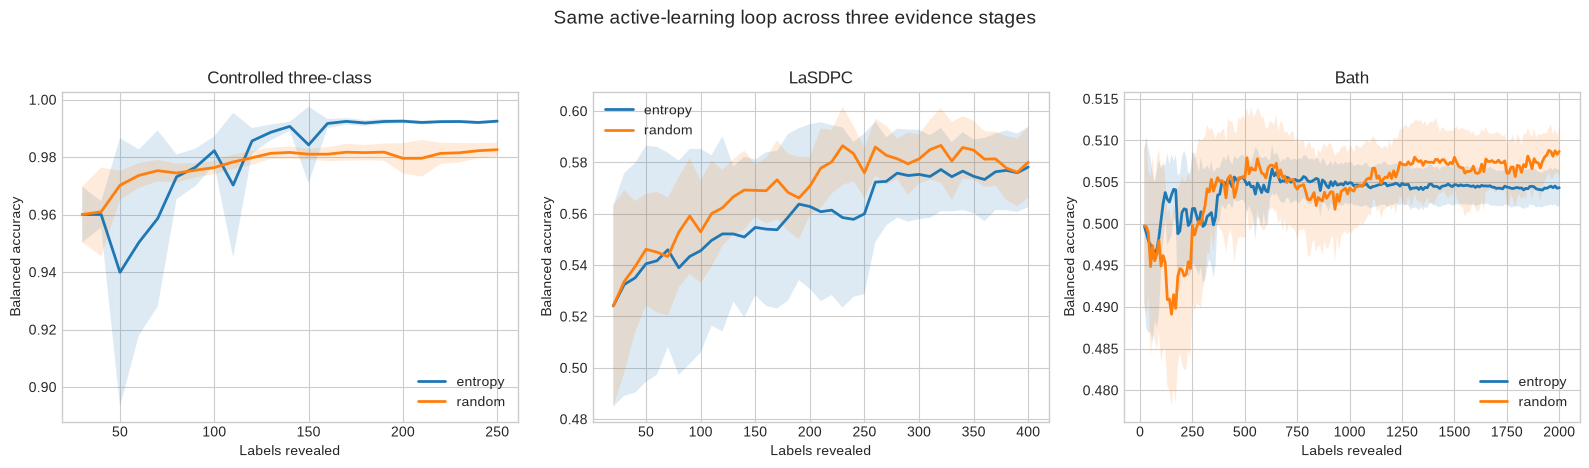

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (stage, runs) in zip(axes, stage_runs.items()):
    curve = analysis.learning_curve(runs, metric="balanced_accuracy")
    for strategy, group in curve.groupby("strategy"):
        group = group.sort_values("n_labels")
        ax.plot(group["n_labels"], group["mean"], label=strategy, linewidth=2)
        ax.fill_between(group["n_labels"], group["ci_lower"], group["ci_upper"], alpha=0.15)
    ax.set(title=stage, xlabel="Labels revealed", ylabel="Balanced accuracy")
    ax.legend()
plt.suptitle("Same active-learning loop across three evidence stages", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

### Block 11 result

The controlled entropy curve separates early and remains above random. LaSDPC and Bath show
overlapping curves and confidence bands. The visual evidence therefore agrees with the paired
statistical tests: one controlled success and two real-data null results.

## Block 12 — Inspect what entropy queried

**Why this block exists:** Even when accuracy does not improve, the research question asks whether
query behaviour differs in a measurable way. These are descriptive proxy observations, not claims
about what a real human would find useful.

,dataset,strategy,queries,temperature_mean,rh_mean,triggered_share,zone_seed_tvd,month_seed_tvd
0,Bath,entropy,19800,14.1023,72.4132,0.9995,0.0887,0.0787
1,Bath,random,19800,14.4300,71.6951,0.9995,0.0333,0.0266
2,LaSDPC,entropy,3800,23.1594,69.6817,0.7674,0.2180,0.0000
3,LaSDPC,random,3800,22.3530,68.3704,0.7234,0.0373,0.0000


**Bath Query Conditions Balanced Review**

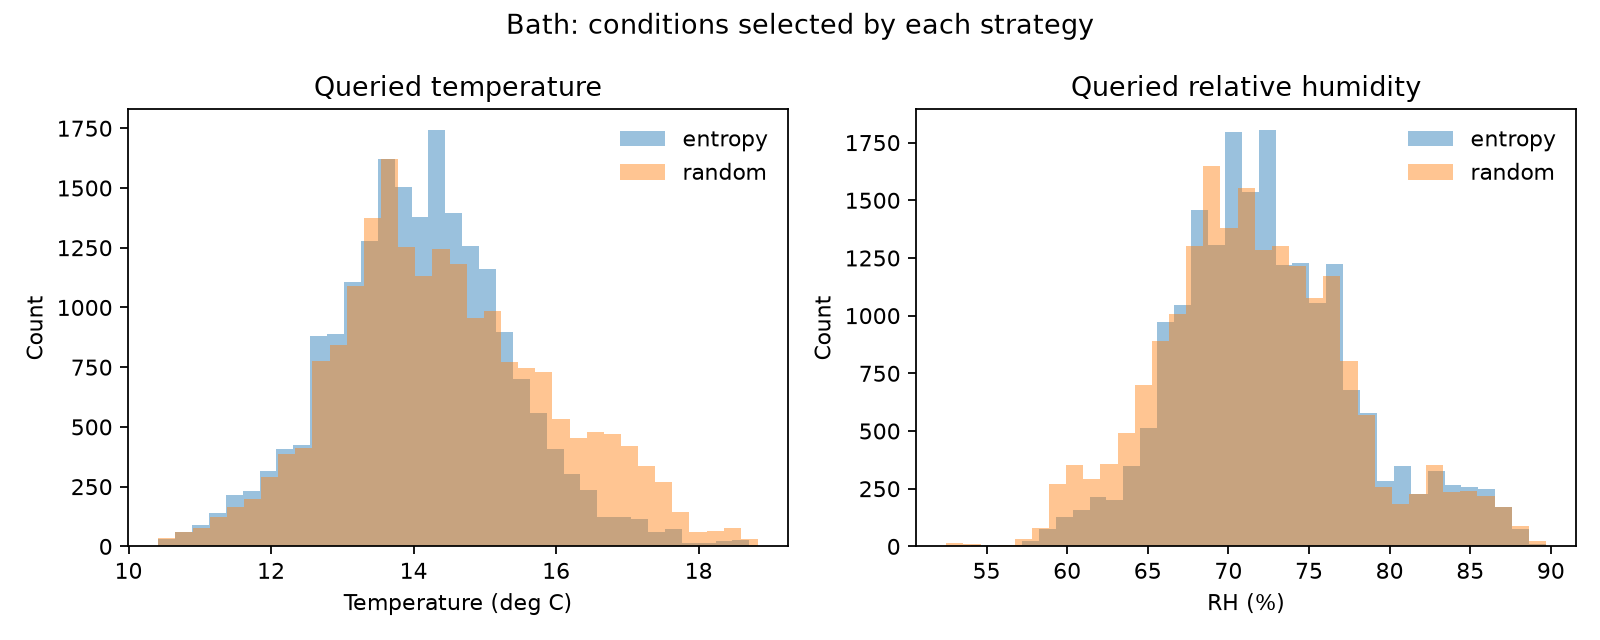

**Bath Query Zone Share Balanced Review**

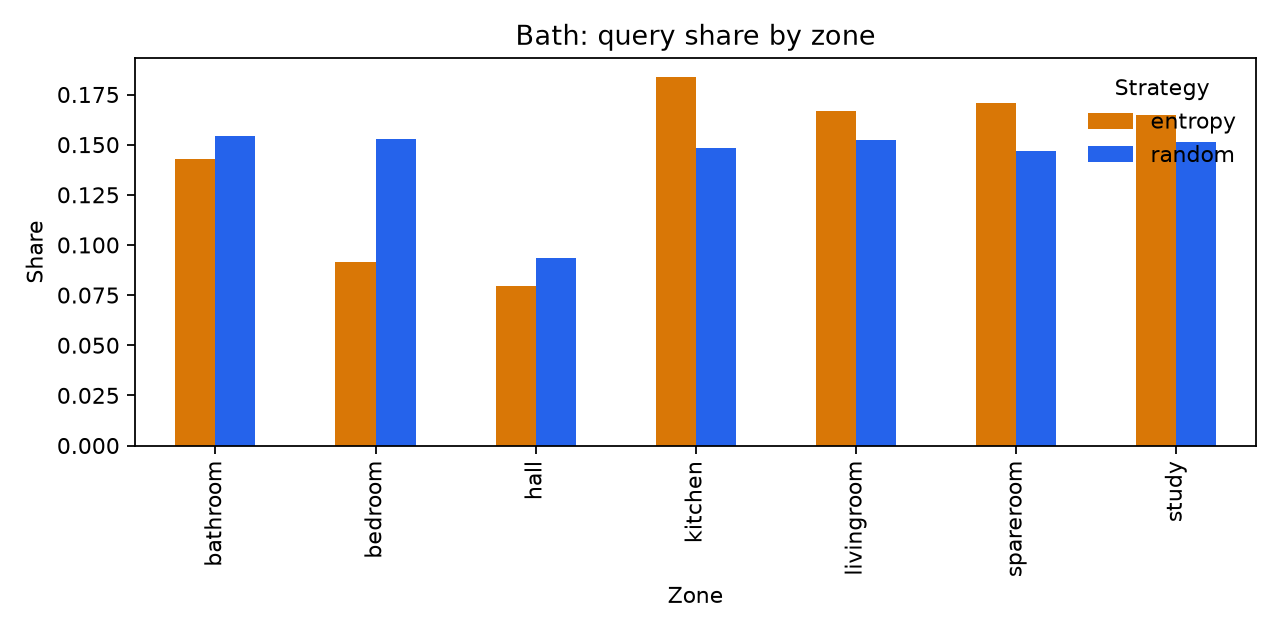

**Lasdpc Query Conditions Balanced Review**

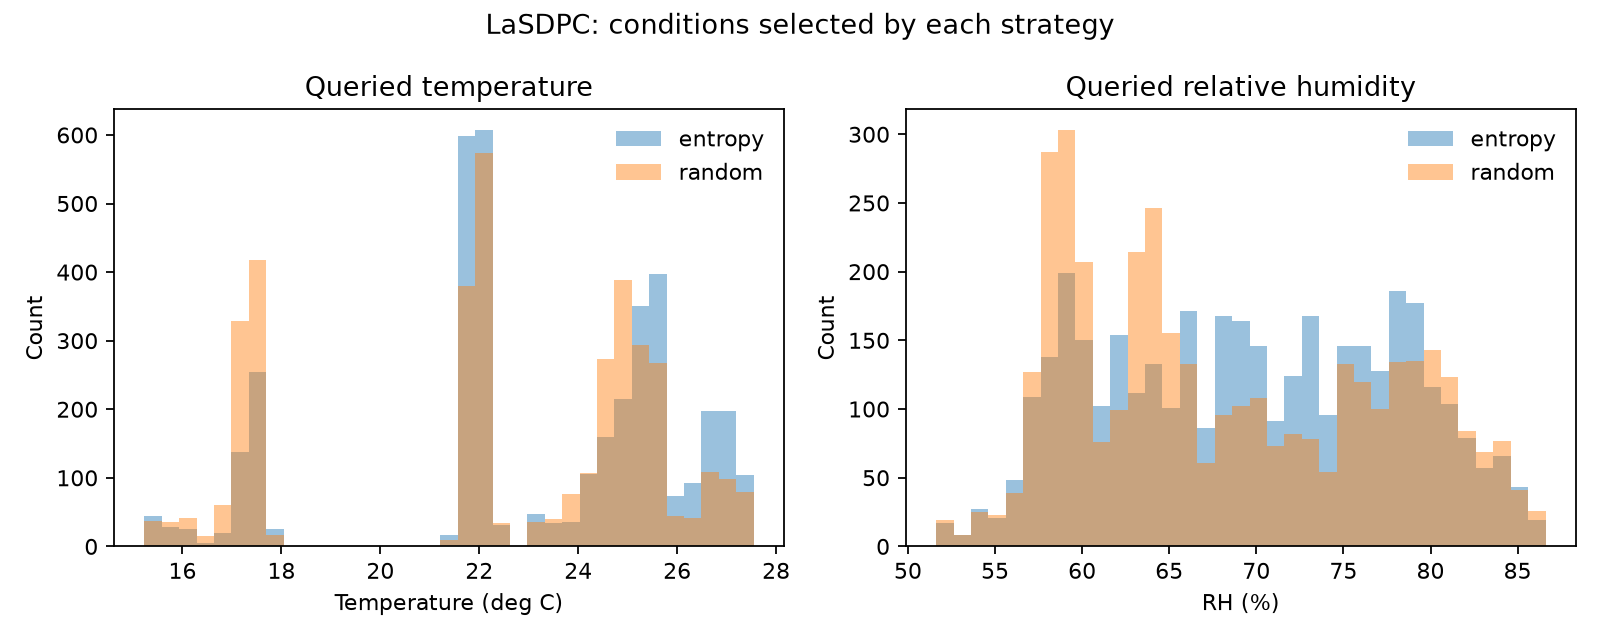

**Lasdpc Query Zone Share Balanced Review**

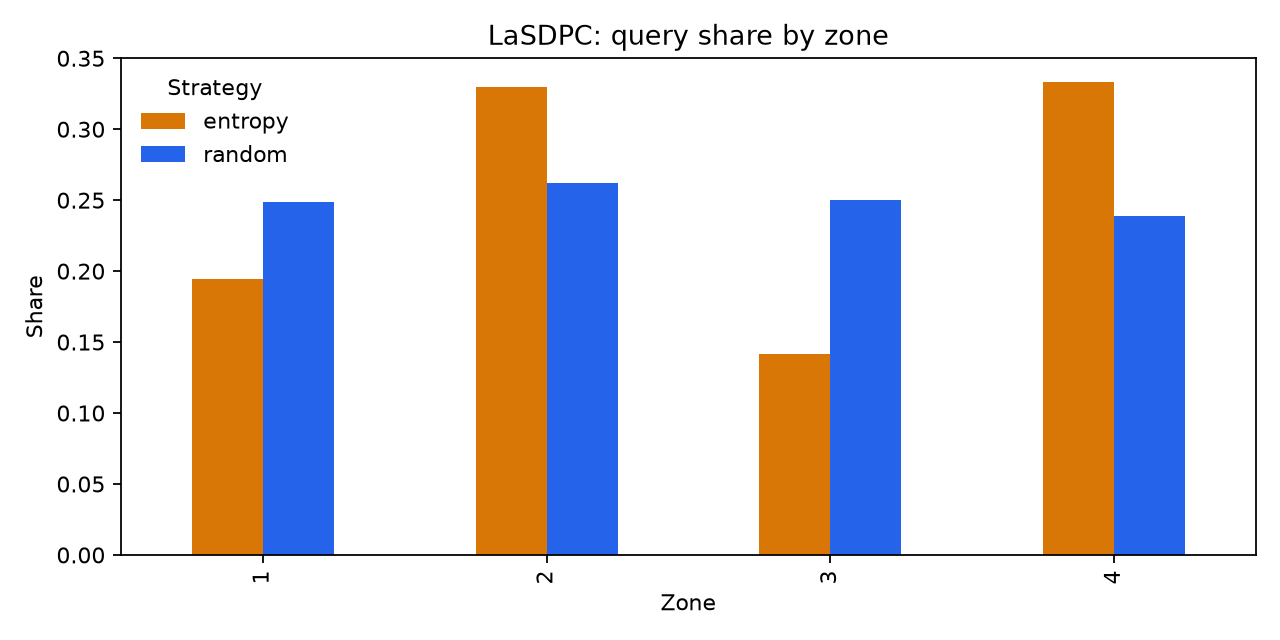

In [13]:
query_summary = pd.read_csv(config.RESULTS_DIR / "query_behaviour_summary.csv")
display(
    query_summary[
        [
            "dataset",
            "strategy",
            "queries",
            "temperature_mean",
            "rh_mean",
            "triggered_share",
            "zone_seed_tvd",
            "month_seed_tvd",
        ]
    ].round(4)
)

for figure_name in (
    "bath_query_conditions_balanced_review.png",
    "bath_query_zone_share_balanced_review.png",
    "lasdpc_query_conditions_balanced_review.png",
    "lasdpc_query_zone_share_balanced_review.png",
):
    figure_path = config.FIGURES_DIR / figure_name
    display(Markdown(f"**{figure_path.stem.replace('_', ' ').title()}**"))
    display(Image(filename=str(figure_path), width=850))

### Block 12 result

Entropy chooses different environmental conditions and room proportions from random sampling.
However, its allocation varies more between seeds, especially on LaSDPC. Different query behaviour
is evidence that uncertainty ranking changes selection; it is not evidence that the selection is
more accurate, stable or useful to real occupants.

## Block 13 — Retrospective SHAP audit

**Why this block exists:** The audit checks whether temperature and RH influence the trained
reference model in understandable ways.

In [14]:
shap_examples = pd.read_csv(config.RESULTS_DIR / "query_shap_examples.csv").rename(
    columns={"final_model_prediction": "reference_model_prediction"}
)
display(
    shap_examples[
        [
            "dataset",
            "strategy",
            "phase",
            "temperature",
            "relative_humidity",
            "observed_label",
            "reference_model_prediction",
            "temperature_shap",
            "rh_shap",
            "dominant_feature",
        ]
    ].round(4)
)

,dataset,strategy,phase,temperature,relative_humidity,observed_label,reference_model_prediction,temperature_shap,rh_shap,dominant_feature
0,Bath,entropy,early,17.3170,79.1000,comfortable,comfortable,0.4364,0.0604,temperature
1,Bath,entropy,middle,14.9340,72.7000,comfortable,comfortable,0.0231,0.1862,relative_humidity
2,Bath,entropy,late,13.9220,86.8000,too_cool,too_cool,0.1136,0.2421,relative_humidity
3,Bath,random,early,16.1980,74.1000,comfortable,comfortable,0.1822,0.1685,temperature
4,Bath,random,middle,15.4060,72.4000,comfortable,comfortable,0.3337,0.1019,temperature
5,Bath,random,late,13.8640,73.0000,comfortable,comfortable,0.0924,0.0583,temperature
6,LaSDPC,entropy,early,27.0238,57.1414,comfortable,comfortable,0.1639,0.4031,relative_humidity
7,LaSDPC,entropy,middle,26.6810,69.2700,comfortable,too_warm,0.1489,0.0400,temperature
8,LaSDPC,entropy,late,22.1280,84.9520,comfortable,comfortable,0.1053,0.5217,relative_humidity
9,LaSDPC,random,early,17.1368,57.1867,comfortable,too_cool,0.2457,0.0216,temperature


### Block 13 result

Temperature dominates some reference predictions and RH dominates others, showing that both
allowed features contribute. This is a retrospective audit of representative cases; it does not
reconstruct the exact model state or causal reason at the historical selection moment.

# Phase 5 - Validation and Robustness

## Block 14 - Validate the final Bath baseline and inspect class errors

**Why this block exists:** Overall accuracy can hide majority-class prediction. Balanced accuracy,
per-class recall and the confusion matrix reveal whether the system actually detects discomfort.

In [15]:
final_model = al.train_static_baseline(pool)
report = validation.validate(final_model, test_set)

summary = pd.Series(
    {
        "test rows": report.n_samples,
        "accuracy": report.accuracy,
        "majority baseline": report.majority_class_rate,
        "balanced accuracy": report.balanced_accuracy,
        "macro F1": report.macro_f1,
        "Brier score": report.brier_score,
    },
    name="Bath static baseline",
).to_frame()

display(summary.round(4))
display(report.per_class.round(4))
display(report.confusion)

,Bath static baseline
test rows,25000.0000
accuracy,0.5596
majority baseline,0.5762
balanced accuracy,0.5096
macro F1,0.4729
Brier score,0.3201


,class,precision,recall,f1,support
0,comfortable,0.5819,0.8376,0.6867,14405
1,too_cool,0.4513,0.1817,0.2591,10595


predicted,comfortable,too_cool
actual,,
comfortable,12065,2340
too_cool,8670,1925


### Block 14 result — why the Bath predictor is not operationally successful

- Model accuracy: approximately **0.5596**
- Trivial majority baseline: approximately **0.5762**
- Balanced accuracy: approximately **0.5096**
- `too_cool` recall: approximately **0.1817**
- **8,670 of 10,595** actual `too_cool` cases are predicted `comfortable`.

The model mainly predicts the majority class and misses most simulated discomfort. It therefore
cannot support a claim of reliable discomfort notification.

## Block 15 — Check calibration and actionable confidence

**Why this block exists:** Entropy selects queries from predicted probabilities. If those
probabilities are misleading, uncertainty sampling is ranking a distorted signal.

In [16]:
calibration_table = validation.calibration_curve(final_model, test_set)
risk_coverage = validation.risk_coverage(final_model, test_set)

features = [schema.TEMPERATURE, schema.RELATIVE_HUMIDITY]
y_pool = (pool[sl.COMFORT_CLASS] == config.COMFORT_CLASS_TOO_COOL).astype(int)
y_test = (test_set[sl.COMFORT_CLASS] == config.COMFORT_CLASS_TOO_COOL).astype(int).to_numpy()
calibrated = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=config.N_ESTIMATORS, random_state=config.RANDOM_SEED),
    method="isotonic",
    cv=3,
).fit(pool[features], y_pool)
probability = calibrated.predict_proba(test_set[features])[:, 1]
actionability = pd.DataFrame(
    {
        "threshold": [0.50, 0.60, 0.70, 0.80],
        "coverage": [(probability >= threshold).mean() for threshold in (0.50, 0.60, 0.70, 0.80)],
    }
)

display(calibration_table.round(4))
display(risk_coverage.round(4))
print(f"Observed too-cool base rate: {y_test.mean():.4f}")
print(f"Maximum calibrated P(too_cool): {probability.max():.4f}")
display(actionability.round(4))

,bin,bin_lower,bin_upper,mean_predicted,observed_frequency,count
0,0,0.0,0.1,0.0418,0.3919,8822
1,1,0.1,0.2,0.1428,0.4229,4845
2,2,0.2,0.3,0.2479,0.4438,3378
3,3,0.3,0.4,0.3472,0.4441,1975
4,4,0.4,0.5,0.4464,0.4655,1637
5,5,0.5,0.6,0.5483,0.4421,1425
6,6,0.6,0.7,0.6520,0.4728,1214
7,7,0.7,0.8,0.7467,0.4510,980
8,8,0.8,0.9,0.8429,0.4362,486
9,9,0.9,1.0,0.9343,0.3908,238


,threshold,n_acted,coverage,precision,recall,base_rate,lift_over_base
0,0.50,4343,0.1737,0.4492,0.1841,0.4238,0.0254
1,0.60,2968,0.1187,0.4532,0.1269,0.4238,0.0294
2,0.70,1742,0.0697,0.4397,0.0723,0.4238,0.0159
3,0.80,724,0.0290,0.4213,0.0288,0.4238,-0.0025
4,0.90,238,0.0095,0.3908,0.0088,0.4238,-0.0330
5,0.95,75,0.0030,0.3733,0.0026,0.4238,-0.0505


Observed too-cool base rate: 0.4238
Maximum calibrated P(too_cool): 0.4784


,threshold,coverage
0,0.5,0.0
1,0.6,0.0
2,0.7,0.0
3,0.8,0.0


### Block 15 result

The uncalibrated model appears very confident, but actual `too_cool` frequency stays roughly
between 0.39 and 0.47. After calibration, maximum `P(too_cool)` is only about **0.4784**, with zero
coverage at thresholds of 0.50 or higher.

The honest system response is therefore **abstain because confidence is insufficient**, not
“everyone is comfortable.”

## Block 16 — Test alternative features and clothing assumptions

**Why this block exists:** These tests check whether the null result is merely caused by omitting a
simple feature, seasonal leakage, or one clothing setting.

In [17]:
circularity = robustness.circularity_check(labelled, pool_size=5_000, seeds=(42, 43, 44))
circularity_summary = robustness.summarise_circularity(circularity)
clothing_summary = robustness.clothing_sensitivity(with_clo, pool_size=5_000, seeds=(42, 43))
# Presentation-only wording correction for a legacy variant identifier. Numerical results are unchanged.
clothing_summary_for_presentation = clothing_summary.copy()
clothing_summary_for_presentation["variant"] = clothing_summary_for_presentation["variant"].replace(
    {"fixed_0.5_inherited": "fixed_0.5_initial"}
)
clothing_summary_for_presentation["description"] = clothing_summary_for_presentation[
    "description"
].str.replace(
    "the inherited LaSDPC assumption",
    "the initial light-clothing implementation assumption",
    regex=False,
)

display(Markdown("**Feature and season ablations**"))
display(circularity_summary.round(4))
display(Markdown("**Clothing-rule sensitivity**"))
display(clothing_summary_for_presentation.round(4))

**Feature and season ablations**

,arm,features,mean,std,count,majority_class_rate,lift_over_majority,share_of_full_lift
0,temperature_only,temperature,0.5553,0.0028,3,0.5762,-0.0209,0.8730
1,full,"temperature, relative_humidity",0.5523,0.0070,3,0.5762,-0.0239,1.0000
2,humidity_only,relative_humidity,0.5060,0.0015,3,0.5762,-0.0702,2.9315
3,month_only,month,0.4238,0.0000,3,0.5762,-0.1524,6.3677


**Clothing-rule sensitivity**

,variant,description,seed,n_classes,too_cool_share,mean_clo,accuracy,estimated_max_accuracy,ceiling_ratio,degenerate
0,adopted,"Outdoor-driven, adopted parameters (DD-017)",42,2,0.4351,0.9766,0.5550,0.5775,0.9609,False
1,adopted,"Outdoor-driven, adopted parameters (DD-017)",43,2,0.4351,0.9766,0.5575,0.5775,0.9653,False
2,fixed_1.0,"Fixed 1.0 clo — a business suit, ISO 7730's wi...",42,2,0.4193,1.0000,0.6702,0.7367,0.9098,False
3,fixed_1.0,"Fixed 1.0 clo — a business suit, ISO 7730's wi...",43,2,0.4193,1.0000,0.6804,0.7367,0.9235,False
4,fixed_1.25,Fixed 1.25 clo — suit plus a jumper,42,2,0.2606,1.2500,0.7444,0.8484,0.8774,False
5,fixed_1.25,Fixed 1.25 clo — suit plus a jumper,43,2,0.2606,1.2500,0.7682,0.8484,0.9055,False
6,shallow_slope,Outdoor-driven but half as responsive to outdo...,42,2,0.3305,1.1133,0.6752,0.7510,0.8991,False
7,shallow_slope,Outdoor-driven but half as responsive to outdo...,43,2,0.3305,1.1133,0.6934,0.7510,0.9232,False
8,steep_slope,Outdoor-driven but twice as responsive,42,2,0.6103,0.7973,0.5018,0.6508,0.7710,False
9,steep_slope,Outdoor-driven but twice as responsive,43,2,0.6103,0.7973,0.5038,0.6508,0.7741,False


### Block 16 result

Temperature-only, RH-only, month-only and full temperature-plus-RH alternatives do not beat the
majority baseline. This weakens the explanation that a simple missing feature or calendar leakage
caused the null.

A fixed `1.25 clo` rule can produce much higher apparent accuracy, but it also changes the labels
and class balance. A higher score under a different oracle is sensitivity evidence, not proof that
the alternative assumption is more valid.

# Phase 6 — Provenance and Final Conclusion

## Block 17 — Bind the conclusion to the computed evidence

**Why this block exists:** The assertions prevent the written conclusion from silently disagreeing
with the results after a future rerun. The same cell also records the configuration used to produce
the presentation evidence.

In [18]:
balanced_indexed = balanced.set_index("stage")
entropy_efficiency = efficiency_table.loc[
    efficiency_table["strategy"].eq("entropy")
].set_index("stage")

checks = {
    "controlled target contains all three classes": controlled_pool[sl.COMFORT_CLASS].nunique() == 3,
    "controlled entropy improves balanced accuracy": balanced_indexed.loc[
        "Controlled three-class", "entropy - random"
    ] > 0,
    "controlled paired confidence interval excludes zero": balanced_indexed.loc[
        "Controlled three-class", "95% CI low"
    ] > 0,
    "LaSDPC has no balanced-accuracy advantage": balanced_indexed.loc[
        "LaSDPC", "entropy - random"
    ] <= 0,
    "Bath has no balanced-accuracy advantage": balanced_indexed.loc[
        "Bath", "entropy - random"
    ] <= 0,
    "Bath preflight warned of insufficient headroom": not signal.is_learnable,
    "Bath model does not beat the majority baseline": report.accuracy <= report.majority_class_rate,
}
display(pd.Series(checks, name="supported by evidence").to_frame())
assert all(checks.values())

commit = subprocess.run(
    ["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True
).stdout.strip()
print("\nProvenance")
print(f"Executed at UTC:   {datetime.now(timezone.utc).isoformat(timespec='seconds')}")
print(f"Source commit:     {commit or 'unknown'}")
print(f"Python:            {sys.version.split()[0]}")
print(f"Random seed:       {config.RANDOM_SEED}")
print(f"Experiment seeds:  {config.EXPERIMENT_SEEDS}")
print(f"Pool/test sizes:   {config.POOL_SIZE:,} / {config.TEST_SET_SIZE:,}")
print(f"Bath label budget: {config.EXPERIMENT_LABEL_BUDGET:,}")
print(f"Noise sigma:       {config.NOISE_STD}")
print(f"Temporal cutoff:   {config.TEMPORAL_SPLIT_CUTOFF}")

,supported by evidence
controlled target contains all three classes,True
controlled entropy improves balanced accuracy,True
controlled paired confidence interval excludes zero,True
LaSDPC has no balanced-accuracy advantage,True
Bath has no balanced-accuracy advantage,True
Bath preflight warned of insufficient headroom,True
Bath model does not beat the majority baseline,True



Provenance
Executed at UTC:   2026-08-17T18:09:25+00:00
Source commit:     23e43ca
Python:            3.14.2
Random seed:       42
Experiment seeds:  (42, 43, 44, 45, 46, 47, 48, 49, 50, 51)
Pool/test sizes:   20,000 / 25,000
Bath label budget: 2,000
Noise sigma:       1.0
Temporal cutoff:   2024-05-01


### Block 17 result

Every statement required for the conclusion evaluates to `True`. The evidence is tied to the
recorded seed, data split, label budget, noise assumption and source revision.

## Final conclusion — what happened

### What I completed

- Loaded and quality-checked the final Bath sensor dataset.
- Tested and corrected the initial light-clothing implementation assumption that caused an
  effectively one-sided Bath PMV screen.
- Generated auditable synthetic PMV-plus-noise feedback.
- Added a preflight that checks whether the generated labels are learnable.
- Implemented temporal splitting, pool construction, entropy querying, random baselines and
  repeated matched-seed evaluation.
- Analysed learning curves, label efficiency, query composition, SHAP examples, calibration,
  per-class errors and robustness.

### What succeeded

The production active-learning loop succeeds on the controlled learnable three-class target.
Entropy reaches random's balanced-accuracy target using **120 instead of 250 labels**, a **52%**
saving, and wins across all ten seeds.

### What failed

- **LaSDPC:** the earlier raw-accuracy success was incorrect. With matched seeds and balanced
  accuracy, entropy is `-0.0019` below random with `p ≈ 0.850`.
- **Bath:** entropy is `-0.0044` below random in balanced accuracy and never reaches random's target.
- The final Bath model misses most `too_cool` cases and has no confidently actionable calibrated
  subset.

### Why it failed on the real datasets

The real sensor targets combine limited or compressed comfort signal with large independent
synthetic-response noise. Entropy therefore concentrates on noisy uncertainty rather than learning
a stable class boundary. Bath's preflight predicted this outcome before model comparison.

### Defensible dissertation claim

> The proof of concept demonstrates that the active-learning implementation can be label-efficient
> when a learnable temperature-and-humidity boundary exists. Under the current noisy synthetic
> oracles, that benefit does not transfer to LaSDPC or Bath. The null results are therefore findings
> about the current data-to-label relationship, not evidence that the software loop is broken.

### What must not be claimed

- No validated real-occupant comfort accuracy.
- No demonstrated Bath `too_warm` performance.
- No evidence that real people would find the selected questions useful.
- No deployment-ready “quiet when normal, notify when uncomfortable” predictor yet.